In [65]:
import numpy as np

In [66]:
import pandas as pd

In [67]:
import matplotlib.pyplot as plt

In [68]:
import seaborn as sns

In [69]:
import warnings

In [70]:
warnings.filterwarnings('ignore')

In [100]:
ds = pd.read_csv('titanic_dataset.csv')

In [79]:
ds

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [80]:
ds.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: xlabel='Parch', ylabel='Count'>

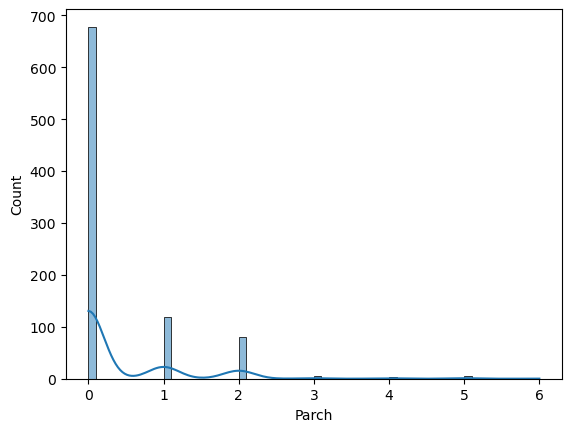

In [11]:
sns.histplot(ds.Parch,kde=True)


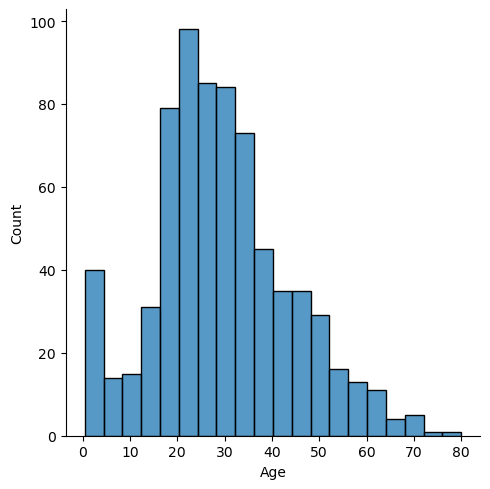

In [16]:
sns.displot(ds.Age)

<Axes: xlabel='Age', ylabel='Density'>

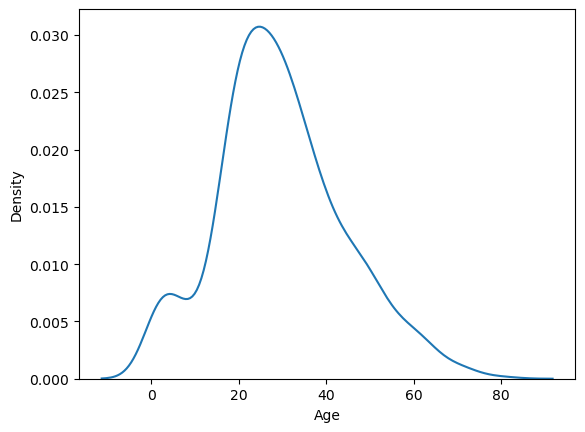

In [17]:
sns.distplot(ds.Age,hist= False)

<Axes: xlabel='Age', ylabel='Density'>

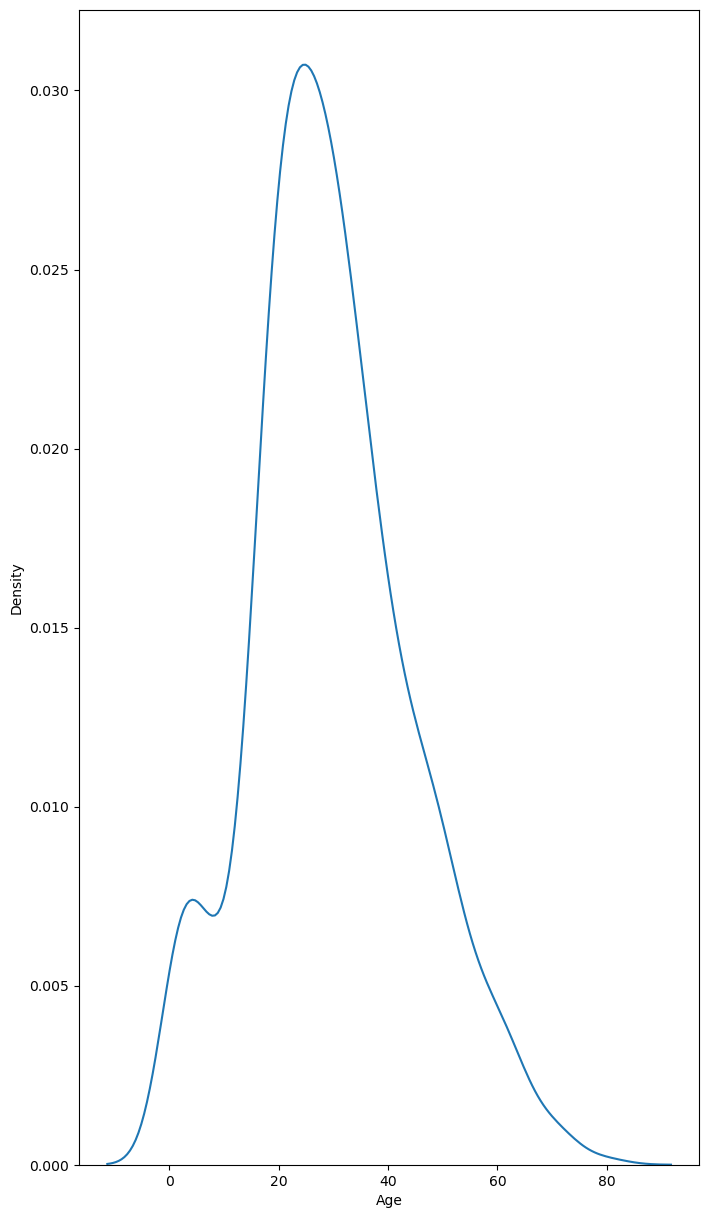

In [21]:
plt.figure(figsize=(8,15))
sns.distplot(ds.Age,hist= False)

In [81]:
ds.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

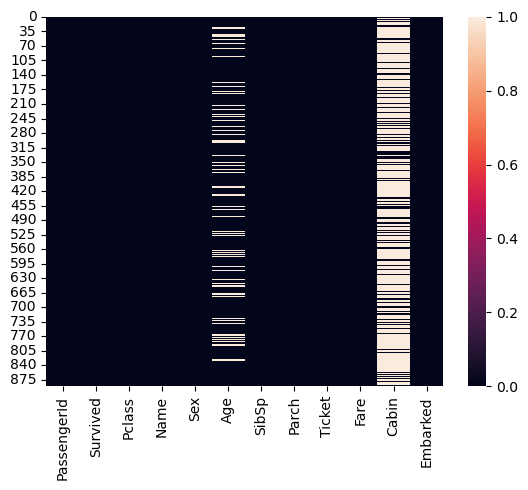

In [24]:
sns.heatmap(ds.isnull())

Text(0.5, 1.0, 'Missing Data')

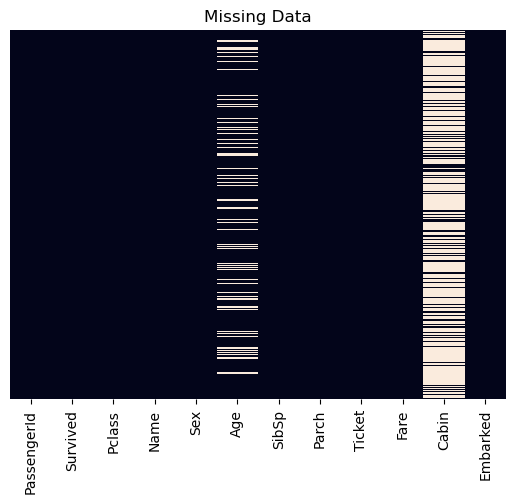

In [28]:
sns.heatmap(ds.isnull(),yticklabels=False,cbar=False)
plt.title('Missing Data')

<Axes: ylabel='Age'>

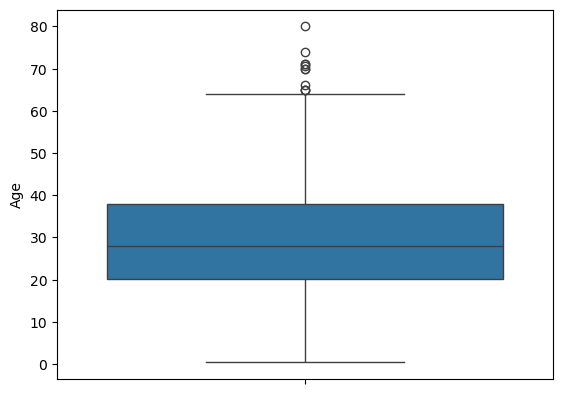

In [30]:
sns.boxplot(ds.Age)

In [33]:
Q1 = ds.Age.quantile(0.25)
Q3 = ds.Age.quantile(0.75)
IQR= Q3-Q1
print(Q1)
print(Q3)
print(IQR)

20.125
38.0
17.875


In [37]:
L_W =Q1 -1.5 * IQR
H_W =Q3 +1.5 * IQR
print(L_W)
print(H_W)

-6.6875
64.8125


In [101]:
ds_Filterd=ds[(ds.Age >= L_W) & (ds.Age <= H_W)]
print(f'OG Rows:{ds.shape[0]},F Row:{ds_Filterd.shape[0]}')

OG Rows:891,F Row:703


Text(0.5, 1.0, 'Age by Pessenger')

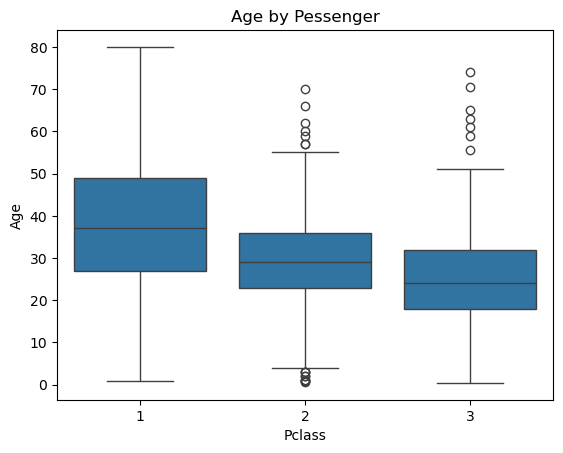

In [102]:
sns.boxplot(y = ds.Age , x = ds.Pclass).set_title('Age by Pessenger')

In [103]:
# Making Function for edit age by class medion
def imputeage(cols):
    Age = cols[0]
    PClass = cols[1]

    if pd.isnull(Age):
        if PClass ==  1:
            return 37
        elif PClass == 2:
            return 29
        else:
            return 24
    else:
        return Age

        

In [104]:
#Running function and adding data replacing data in databse
ds.Age = ds[['Age','Pclass']].apply(imputeage, axis =1)

Text(0.5, 1.0, 'Age by Pessenger')

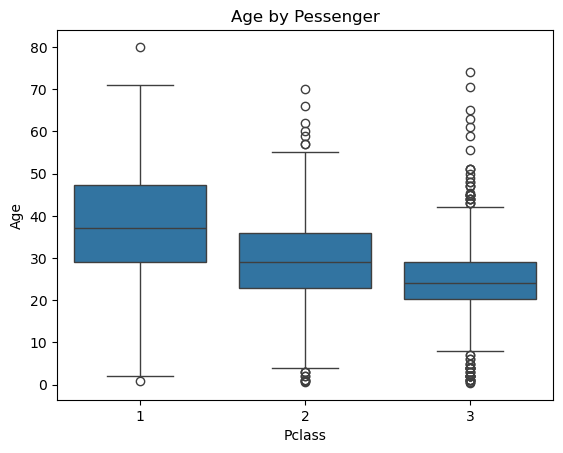

In [105]:
sns.boxplot(y = ds.Age , x = ds.Pclass).set_title('Age by Pessenger')

In [77]:
ds.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    24.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

<Axes: >

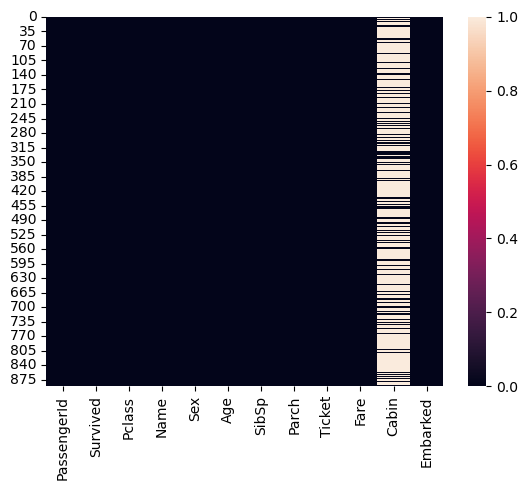

In [88]:
sns.heatmap(ds.isnull())

In [106]:
ds_Filterd_Data=ds[(ds.Age >= L_W) & (ds.Age <= H_W)]
print(f'OG Rows:{ds.shape[0]},F Row:{ds_Filterd_Data.shape[0]}')

OG Rows:891,F Row:880


In [96]:
ds['Age'].isnull().sum()

np.int64(0)

In [97]:
ds.shape

(891, 12)

<Axes: xlabel='Pclass', ylabel='Age'>

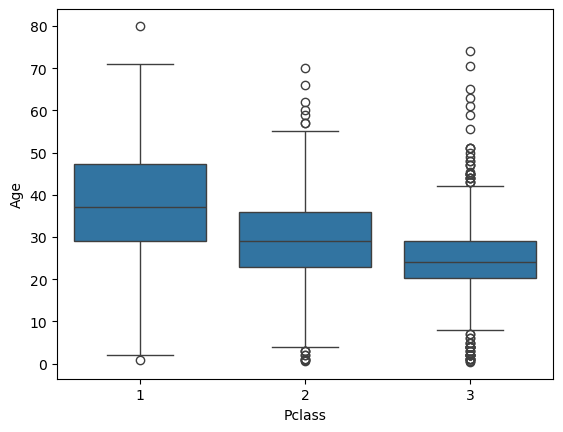

In [99]:
sns.boxplot(x='Pclass', y='Age', data=ds)

In [107]:
## **Relational plots**

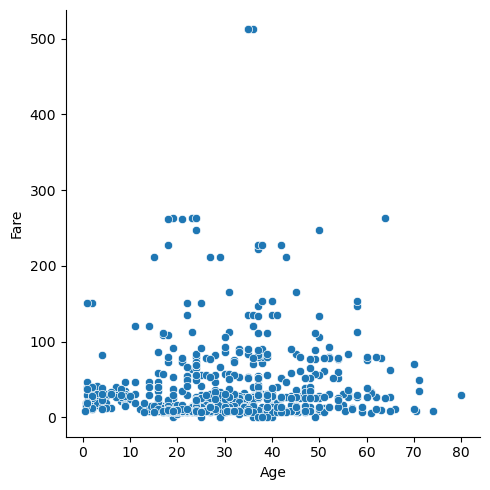

In [109]:
sns.relplot(x= 'Age',y = 'Fare',data=ds)

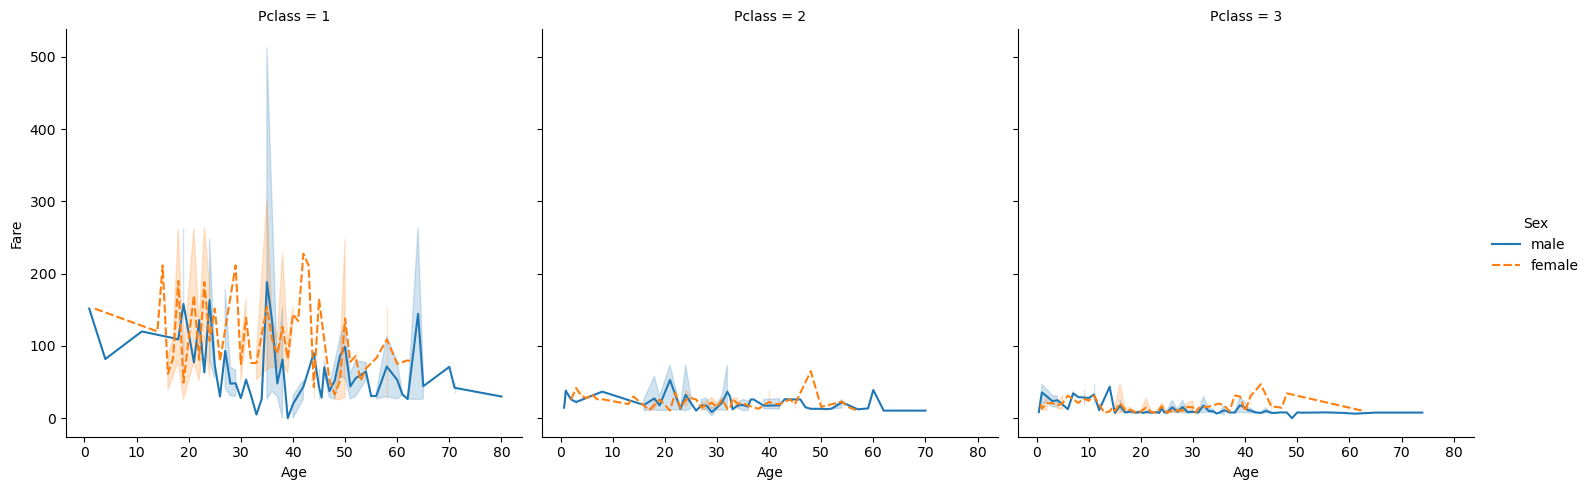

In [112]:
sns.relplot(x="Age", y="Fare", col="Pclass", hue="Sex", style="Sex",kind="line", data=ds)

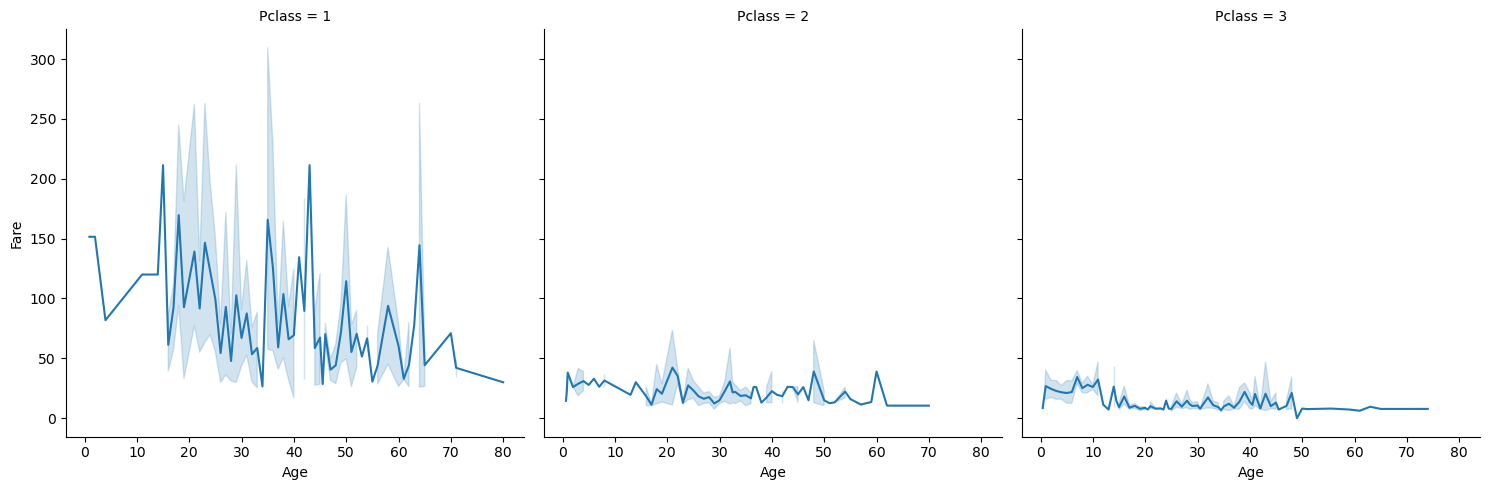

In [113]:
sns.relplot(x="Age", y="Fare", col="Pclass",kind="line", data=ds)

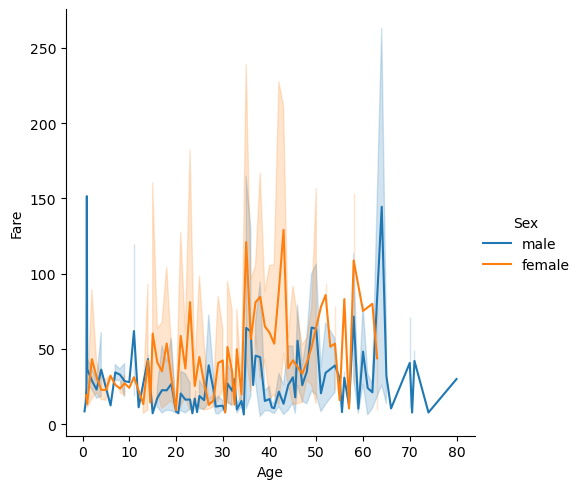

In [114]:
sns.relplot(x="Age", y="Fare",  hue="Sex",kind="line", data=ds)

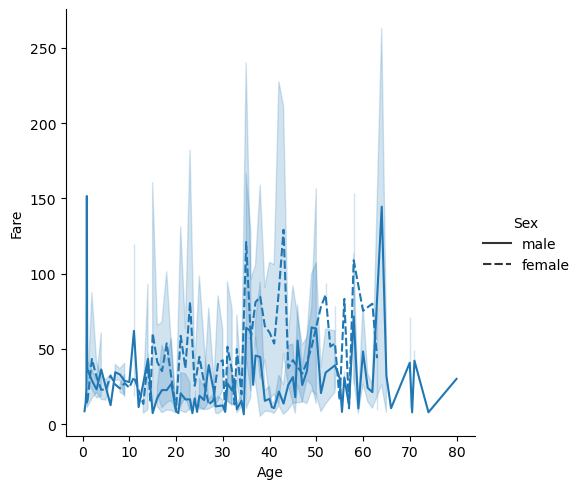

In [115]:
sns.relplot(x="Age", y="Fare", style="Sex",kind="line", data=ds)

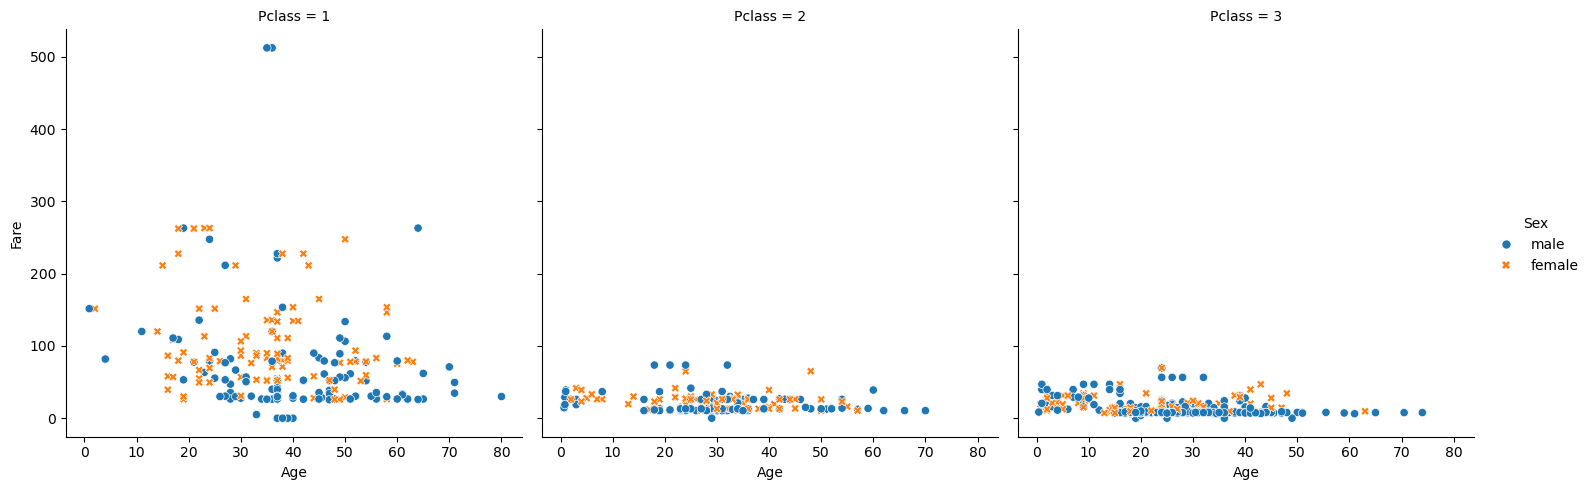

In [117]:
# scatter can be used instead of "line" plot
sns.relplot(x="Age", y="Fare", col="Pclass", hue="Sex", style="Sex", data=ds)
plt.show()

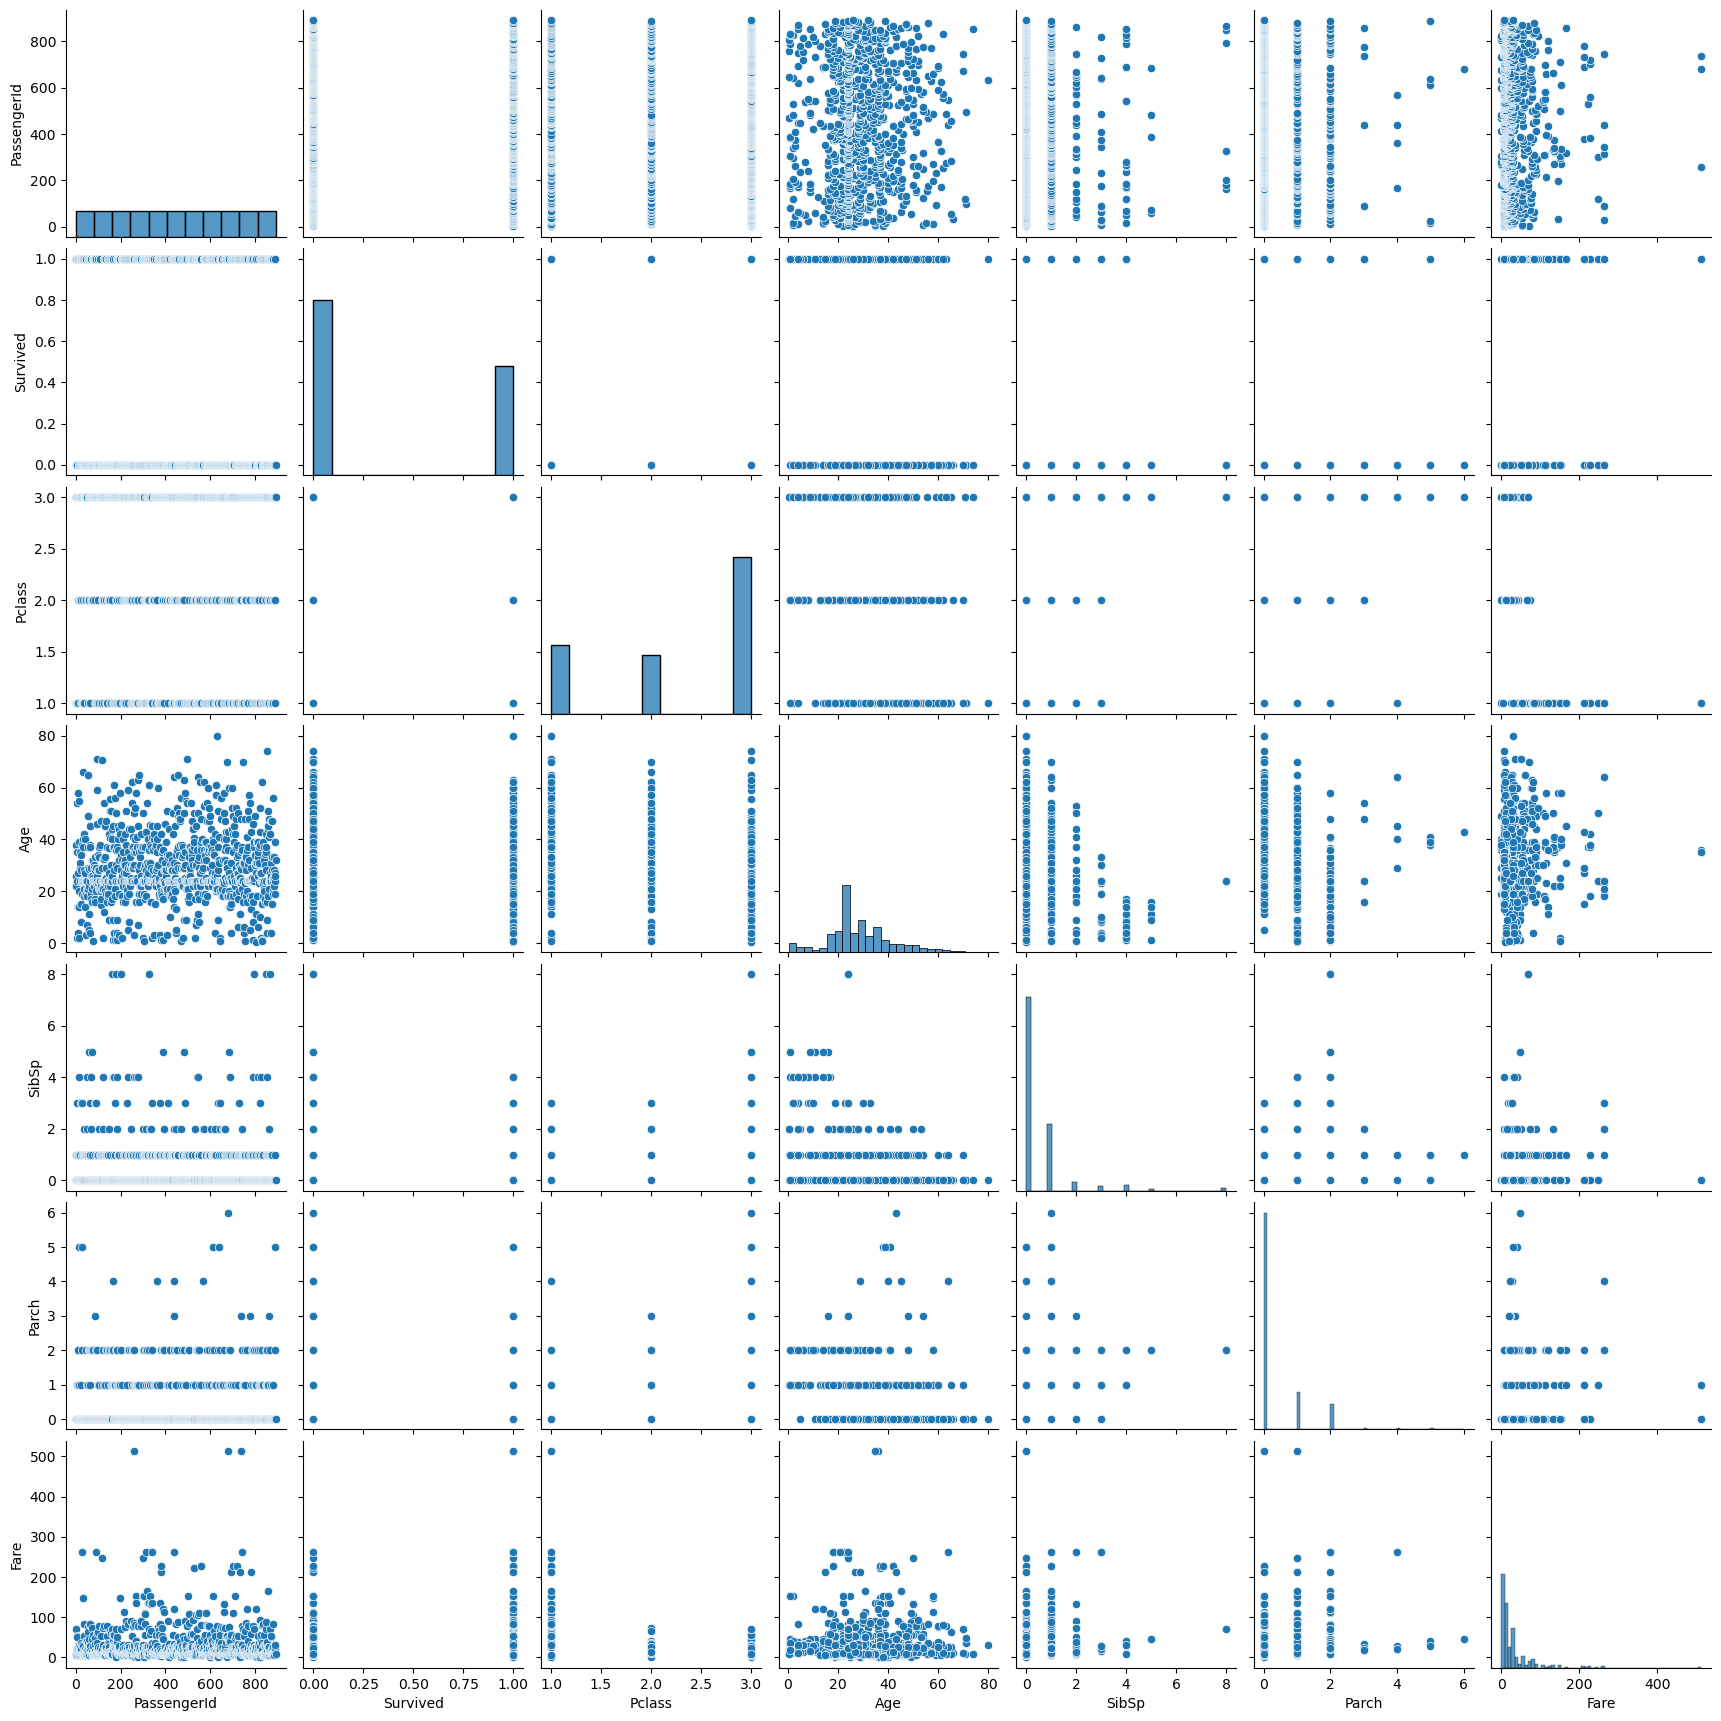

In [118]:
sns.pairplot(data=ds)

In [119]:
#HEAT MAP for ## **Matrix plots**
ds.corr()

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [121]:
numeric_df = ds.select_dtypes(include=['float64', 'int64'])
numeric_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,24.0,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [122]:
numeric_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
dtype: object

In [123]:
numeric_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.035840,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.047255,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.408487,0.083081,0.018443,-0.549500
Age,0.035840,-0.047255,-0.408487,1.000000,-0.243526,-0.171095,0.123784
SibSp,-0.057527,-0.035322,0.083081,-0.243526,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.171095,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.123784,0.159651,0.216225,1.000000


<Axes: >

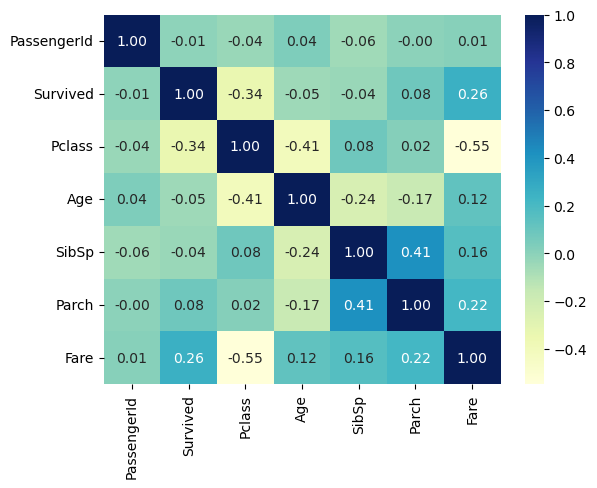

In [126]:
sns.heatmap(numeric_df.corr(), cmap="YlGnBu", annot=True, fmt=".2f")